In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from skimage.exposure import match_histograms

In [3]:
# make dummy track_ops object (would be input from command line or gui)
class Track_ops:
    def __init__(self):
        # input list of dataset paths (each contains a 'suite2p' folder)
        self.all_ds_path = [
            'data/jm/jm032/2023-10-19_a/',
            'data/jm/jm032/2023-10-20_a/',
            'data/jm/jm032/2023-10-21_a/'
        ]
        self.save_path = 'data/jm/jm032/tracking/'
        self.reg_chan = 1 # channel to use for registration (0=functional, 1=anatomical) (1 is not always available)
        self.transform_type = 'affine' # 'affine' or 'nonrigid'
        self.sat_perc = 99 # percentile to saturate image at (only affects visualisation not the registration/matching)

In [4]:
track_ops = Track_ops()

In [5]:
# first check how many planes in each dataset
all_n_planes = []

for ds_path in track_ops.all_ds_path:
    # check how many subfolders starting with plane* in suite2p folder
    n_planes = len([name for name in os.listdir(ds_path + 'suite2p') if name.startswith('plane')])
    print(f'Found {n_planes} planes in {ds_path}')
    all_n_planes.append(n_planes)
track_ops.all_n_planes = all_n_planes
# TODO (handling exceptions of no suite2p folder, no plane folders, not matching number of folders etc. )

Found 1 planes in data/jm/jm032/2023-10-19_a/
Found 1 planes in data/jm/jm032/2023-10-20_a/
Found 1 planes in data/jm/jm032/2023-10-21_a/


In [6]:
def load_all_imgs(track_ops):
    all_ds_avg_ch1 = []
    all_ds_avg_ch2 = []
    all_ds_nchannels = []

    for ds_path in track_ops.all_ds_path:
        ds_nchannels = []
        ds_avg_ch1 = []
        ds_avg_ch2 = []

        for i in range(n_planes):
            ops = np.load(ds_path + 'suite2p/plane' + str(i) + '/ops.npy', allow_pickle=True).item()
            nchannels = ops['nchannels']
            print('nchannels: ' + str(nchannels) + ' for plane ' + str(i) + ' in dataset ' + ds_path)
            ds_avg_ch1.append(ops['meanImg'])
            ds_avg_ch2.append(ops['meanImg_chan2']) if nchannels==2 else ds_avg_ch2.append(None)
            all_ds_nchannels.append(nchannels)

        all_ds_avg_ch1.append(ds_avg_ch1)
        all_ds_avg_ch2.append(ds_avg_ch2)
        all_ds_nchannels.append(ds_nchannels)

    track_ops.all_ds_avg_ch1 = all_ds_avg_ch1
    track_ops.all_ds_avg_ch2 = all_ds_avg_ch2
    track_ops.all_ds_nchannels = all_ds_nchannels

    return all_ds_avg_ch1, all_ds_avg_ch2

In [7]:
all_ds_avg_ch1, all_ds_avg_ch2 = load_all_imgs(track_ops)

nchannels: 2 for plane 0 in dataset data/jm/jm032/2023-10-19_a/
nchannels: 2 for plane 0 in dataset data/jm/jm032/2023-10-20_a/
nchannels: 2 for plane 0 in dataset data/jm/jm032/2023-10-21_a/


In [8]:
# match histograms (using first plane of first dataset as reference)
def match_hist_all(all_ds_avg_ch):
    ref = all_ds_avg_ch[0][0]
    all_ds_avg_ch_matched = []
    for ds_avg_ch in all_ds_avg_ch:
        ds_avg_ch_matched = []
        for i in range(len(ds_avg_ch)):
            ds_avg_ch_matched.append(match_histograms(ds_avg_ch[i], ref))
        all_ds_avg_ch_matched.append(ds_avg_ch_matched)
        
    return all_ds_avg_ch_matched

In [9]:
track_ops.all_ds_avg_ch1_matched = match_hist_all(all_ds_avg_ch1)
track_ops.all_ds_avg_ch2_matched = match_hist_all(all_ds_avg_ch2)

In [10]:
# define function to plot all planes of a dataset for a particular channel where rows are planes and columns are datasets
def plot_all_planes(all_ds_avg_ch, n_planes, track_ops, sat_perc=99):
    fig, axs = plt.subplots(n_planes, len(track_ops.all_ds_path), figsize=(10, 10))
    # add dummy dimension to axs if only one plane
    if n_planes==1:
        axs = np.expand_dims(axs, axis=0)
    
    all_ds_avg_ch_matched = match_hist_all(all_ds_avg_ch)


    for i in range(n_planes):
        for j in range(len(track_ops.all_ds_path)):
            img = all_ds_avg_ch_matched[j][i]
            axs[i, j].imshow(img, cmap='gray', vmin=0, vmax=np.percentile(img, sat_perc))
            axs[i, j].set_title('Plane ' + str(i) + ' in dataset ' + str(j))
            axs[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

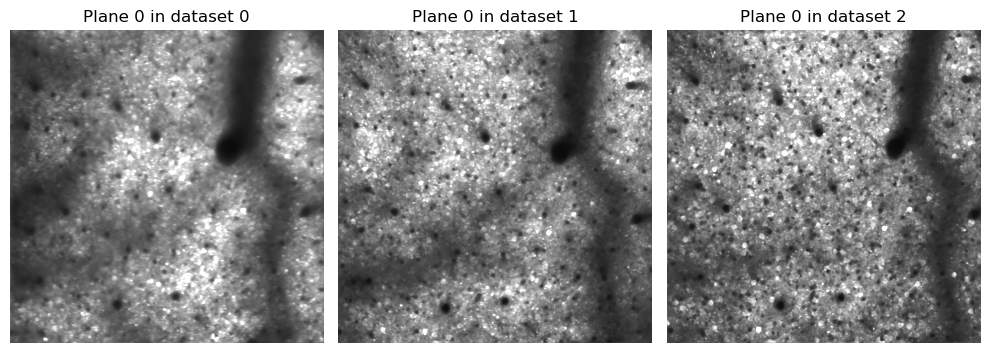

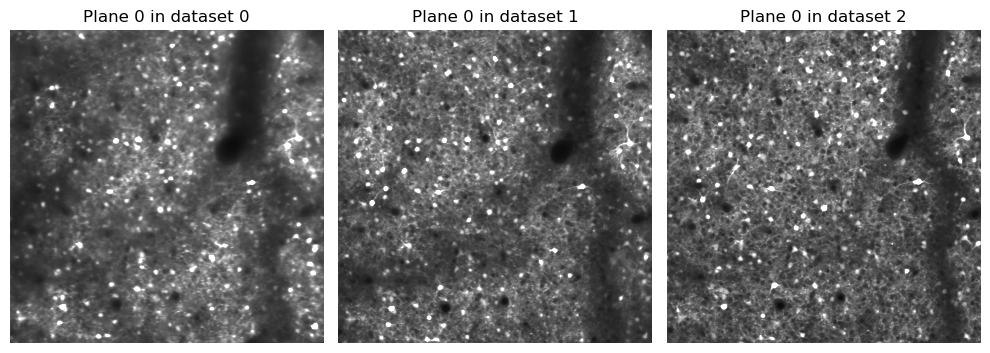

In [11]:
plot_all_planes(all_ds_avg_ch1, n_planes, track_ops)
if track_ops.all_ds_nchannels[0]==2: # if there is a second channel, plot it too
    plot_all_planes(all_ds_avg_ch2, n_planes, track_ops)

In [12]:
# choose 'reference images' for registration (all except last plane of last dataset) based on which channel is used for registration
# if track_ops.reg_chan==0:
#     all_ref_img = [all_ds_avg_ch1[i][j] for i in range(len(track_ops.all_ds_path)-1) for j in range(n_planes)]
#     all_mov_img = [all_ds_avg_ch1[i][j] for i in range(1, len(track_ops.all_ds_path)) for j in range(n_planes)]
# elif track_ops.reg_chan==1:
#     all_ref_img = [all_ds_avg_ch2[i][j] for i in range(len(track_ops.all_ds_path)-1) for j in range(n_planes)]
#     all_mov_img = [all_ds_avg_ch2[i][j] for i in range(1, len(track_ops.all_ds_path)) for j in range(n_planes)]
    

In [13]:
if track_ops.reg_chan==0:
    all_ds_avg = all_ds_avg_ch1
elif track_ops.reg_chan==1:
    all_ds_avg = all_ds_avg_ch2


# loop through planes
all_ds_ref_img = []
all_ds_mov_img = []


for i in range(len(track_ops.all_ds_path)-1):
    ds_ref_img = []
    ds_mov_img = []
    
    for j in range(n_planes):
        ds_ref_img.append(all_ds_avg[i][j])
        ds_mov_img.append(all_ds_avg[i+1][j])

    all_ds_ref_img.append(ds_ref_img)
    all_ds_mov_img.append(ds_mov_img)

track_ops.all_ds_ref_img = all_ds_ref_img
track_ops.all_ds_mov_img = all_ds_mov_img


# Main registration loop (gets the parameters and the reference images)

In [14]:
# try instead with itk elastix
import itk

def register_img_elastix(ref_img, mov_img, transform_type='affine'):
    # convert to itk images
    ref_img_itk = itk.GetImageFromArray(ref_img)
    mov_img_itk = itk.GetImageFromArray(mov_img)
    # define parameter map
    
    # import default parameter map
    parameter_object = itk.ParameterObject.New()
    parameter_map = parameter_object.GetDefaultParameterMap(transform_type)
    parameter_object.AddParameterMap(parameter_map)

    # call registration function
    mov_img_reg_itk, reg_params = itk.elastix_registration_method(
        ref_img_itk,
        mov_img_itk,
        parameter_object = parameter_object
    )
    # get itk transform object from params (avoid this error:  module 'itk' has no attribute 'GetTransform')
    # convert back to numpy array
    mov_img_reg = itk.GetArrayFromImage(mov_img_reg_itk)
    reg_params.SetParameter("FinalBSplineInterpolationOrder", "0")
    return mov_img_reg, reg_params

In [15]:
all_ds_mov_img_reg = []
all_ds_reg_params = []

for (i, ds_ref_img) in enumerate(all_ds_ref_img):
    ds_mov_img = all_ds_mov_img[i]
    ds_mov_img_reg = []
    ds_reg_params = []

    for j in range(n_planes):
        ref_img = ds_ref_img[j]
        mov_img = ds_mov_img[j]
        mov_img_reg,reg_params = register_img_elastix(ref_img, mov_img, transform_type=track_ops.transform_type)
        ds_mov_img_reg.append(mov_img_reg)
        ds_reg_params.append(reg_params)

    all_ds_mov_img_reg.append(ds_mov_img_reg)
    all_ds_reg_params.append(ds_reg_params)
    
track_ops.all_ds_mov_img_reg = all_ds_mov_img_reg
track_ops.all_ds_reg_params = all_ds_reg_params

In [16]:
# define a function that will take two images and return an rgb image
def make_rgb_img(img1, img2):
    img_rgb = np.zeros((img1.shape[0], img1.shape[1], 3))
    # normalise images to 0-1
    img1_norm = (img1 - np.min(img1)) / (np.max(img1) - np.min(img1))
    img2_norm = (img2 - np.min(img2)) / (np.max(img2) - np.min(img2))
    img_rgb[:, :, 0] = img1_norm
    img_rgb[:, :, 1] = img2_norm
    
    return img_rgb

In [17]:
# # compute affine transformation matrix to register the two images
# from skimage.transform import AffineTransform, warp
# from skimage.feature import ORB, match_descriptors

# def compute_affine_transform(ref_img, mov_img, n_keypoints=10):
#     # get key points from both images
#     descriptor_extractor = ORB(n_keypoints=n_keypoints)
#     descriptor_extractor.detect_and_extract(ref_img)
#     keypoints_ref = descriptor_extractor.keypoints
#     descriptors_ref = descriptor_extractor.descriptors
#     descriptor_extractor.detect_and_extract(mov_img)
#     keypoints_mov = descriptor_extractor.keypoints
#     descriptors_mov = descriptor_extractor.descriptors
#     # match keypoints
#     matches12 = match_descriptors(descriptors_ref, descriptors_mov, cross_check=True)
#     # estimate rigid transofrm (not affine, just rotation and translation)
#     transform = AffineTransform()
#     transform.estimate(keypoints_mov[matches12[:, 1]], keypoints_ref[matches12[:, 0]])
    
#     return transform




In [18]:
mov_img_reg, params = register_img_elastix(ref_img, mov_img, transform_type=track_ops.transform_type)

In [19]:
track_ops.all_ds_avg_ch2_matched[1][0]

array([[101.15143 , 128.57347 , 149.15681 , ...,  56.128143,  54.699135,
         60.462044],
       [112.89549 , 148.78197 , 174.37582 , ...,  50.81951 ,  52.505123,
         63.20888 ],
       [117.04898 , 154.46848 , 178.27374 , ...,  50.00745 ,  51.6215  ,
         65.27561 ],
       ...,
       [ 59.527763,  57.60572 ,  57.68481 , ...,  68.375084,  65.3328  ,
         61.85187 ],
       [ 58.812954,  57.382145,  58.740414, ...,  69.878395,  66.35912 ,
         64.067764],
       [ 64.71898 ,  68.443085,  70.785355, ...,  68.199135,  63.469547,
         61.987846]], dtype=float32)

In [20]:
# Transform the moving mask using the result from the
# registration

mov_img_reg_params = itk.transformix_filter(track_ops.all_ds_avg_ch2_matched[1][0],
params)

In [21]:
def saturate_perc(img_rgb, sat_perc=99):
    img_rgb = np.clip(img_rgb, 0, np.percentile(img_rgb, sat_perc)) 
    img_rgb = (img_rgb / np.max(img_rgb) * 255).astype(np.uint8)
    return img_rgb


In [22]:
# big function to plot the outputs
def plot_reg_output(track_ops):
    # make a plot where on the top its all the images and the bottom is the overlays before and after registration
    n_planes = track_ops.all_n_planes[0]
    n_row = n_planes + 2*n_planes # number of plays + 2 overlays per plane
    n_col = len(track_ops.all_ds_path) # number of datasets
    fig, axs = plt.subplots(n_row, n_col, figsize=(10, 10))

    # first populate first (n_planes) rows with images
    for i in range(track_ops.all_n_planes[0]):
        axs[i, 0].set_ylabel(f'plane{i}', rotation=0, size='large', ha='right', va='center', labelpad=20)
        for j in range(len(track_ops.all_ds_path)):
            img = track_ops.all_ds_avg_ch1[j][i]
            axs[i, j].imshow(img, cmap='gray', vmin=0, vmax=np.percentile(img, 99))


    for i in range(len(track_ops.all_ds_path)-1): # last one won't have overlay
        for j in range(n_planes):
            # get subplot indices
            row_nonreg = n_planes + 2*j # first shift for number of initial rows, then shift by 2 for each plane (before and after registration)
            row_reg = n_planes + 2*j + 1 # the row after the nonreg

            # get images
            ref_img = track_ops.all_ds_ref_img[i][j] # get ref image for this pair
            mov_img = track_ops.all_ds_mov_img[i][j] # get mov image for this pair
            mov_img_ref = track_ops.all_ds_mov_img_reg[i][j] # get mov image after registration for this pair

            # match histograms to reference
            mov_img = match_histograms(mov_img, ref_img)
            mov_img_ref = match_histograms(mov_img_ref, ref_img)

            # assemble and saturate the overlays
            img_rgb = make_rgb_img(ref_img, mov_img)
            img_rgb_reg = make_rgb_img(ref_img, mov_img_ref)
            img_rgb = saturate_perc(img_rgb, sat_perc=track_ops.sat_perc)
            img_rgb_reg = saturate_perc(img_rgb_reg, sat_perc=track_ops.sat_perc)

            # plot the overlays
            axs[row_nonreg, i].imshow(img_rgb)
            axs[row_reg, i].imshow(img_rgb_reg)
            
            # get pre and post-registration images form ops
        if i == 0:
            axs[row_nonreg,i].set_ylabel(f'plane{j} \n non-reg', rotation=0, size='large', ha='right', va='center', labelpad=20)
            axs[row_reg,i].set_ylabel(f'plane{j} \n reg', rotation=0, size='large', ha='right', va='center', labelpad=20)

    # loop through all subplots and remove ticks and labels and spines
    for ax in axs.flat:
        ax.set(xticks=[], yticks=[])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

    # add arrows and dashed lines etc.

    axs[2*track_ops.all_n_planes[0], 0].annotate('', xy=(0, 1.1), xytext=(3.5, 1.1), 
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-', linestyle='dashed', color='grey'), 
                annotation_clip=False)

    for i in range(len(track_ops.all_ds_path)-1):
        axs[n_planes-1,i].annotate('', xy=(0.5, -0.17), xytext=(0.5, -0.02), 
                        xycoords='axes fraction', textcoords='axes fraction',
                        arrowprops=dict(facecolor=(1,0,0), edgecolor=(1,0,0), shrink=0.05), 
                        annotation_clip=False)
        axs[n_planes-1,i+1].annotate('', xy=(-0.6, -0.17), xytext=(0.5, -0.02), 
                        xycoords='axes fraction', textcoords='axes fraction',
                        arrowprops=dict(facecolor=(0,1,0), edgecolor=(0,1,0), shrink=0.05), 
                        annotation_clip=False)



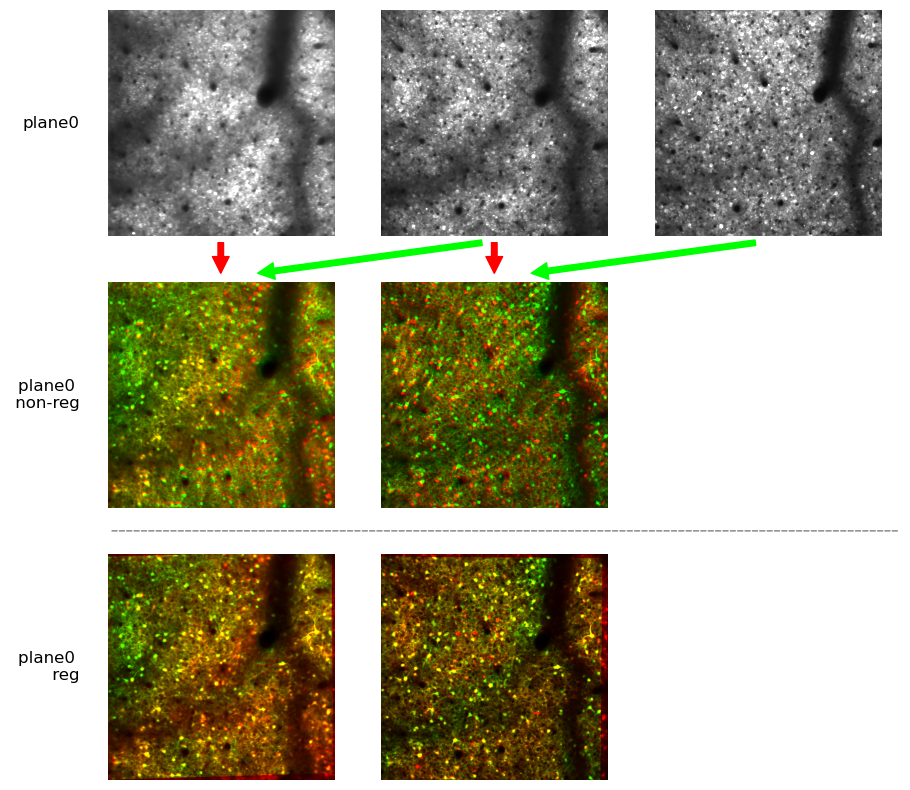

In [23]:
plot_reg_output(track_ops)